In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree

import warnings
warnings.filterwarnings("ignore")

In [29]:
#Create a path to where your data is stored.
path = r'/Users/april/Machine Learning'

In [30]:
#Create a path to where your data is stored.
path2 = r'/Users/april/Machine Learning/Datasets'

In [31]:
# Export weather data
X = pd.read_csv(os.path.join(path, 'weather_clean.csv'), index_col =False)

In [32]:
#Read in the pleasant weather data.
pleasantweather = pd.read_csv(os.path.join(path2, 'Supervised','Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

## Data Wrangling

In [33]:
# Create a list of the columns containing "Belgrade" in their names

belgrade_list = list(x for x in X.columns if x.find('BELGRADE') >=0)
belgrade_list

['BELGRADE_cloud_cover',
 'BELGRADE_humidity',
 'BELGRADE_pressure',
 'BELGRADE_global_radiation',
 'BELGRADE_precipitation',
 'BELGRADE_sunshine',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BELGRADE_temp_max']

In [34]:
# Create a dataframe with those columns

df_belgrade = X[belgrade_list]
df_belgrade

,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max
0,-1.206433,0.905270,0.321771,-0.743149,-0.371315,0.283983,-1.016876,-1.220210,-0.949203
1,0.652846,1.119118,0.016838,-1.418387,-0.371315,-1.333204,-1.107669,-0.818702,-1.298119
2,0.652846,0.620141,0.109644,-0.968228,-0.371315,-0.524611,-1.084971,-1.168403,-1.098738
3,1.396557,1.760659,1.289601,-1.418387,-0.371315,-1.333204,-1.209812,-1.362681,-1.437685
4,1.396557,2.188353,1.528244,-1.418387,-0.253655,-1.333204,-1.209812,-1.012980,-1.457623
...,...,...,...,...,...,...,...,...,...
22945,-0.834577,-0.021400,1.422181,-0.003601,-0.018334,-0.016352,0.628750,0.463536,0.695687
22946,-1.578288,-0.021400,1.647566,-0.003601,-0.018334,-0.016352,0.367720,0.269258,0.376678
22947,-0.834577,-0.021400,1.422181,-0.003601,-0.018334,-0.016352,0.083991,0.010220,0.077607
22948,-1.206433,-0.021400,0.891863,-0.003601,-0.018334,-0.016352,0.265577,0.074979,0.346771


In [35]:
# Reduce answers dataset to Belgrade's answers only

pleasantweather_belgrade =pleasantweather['BELGRADE_pleasant_weather']
pleasantweather_belgrade

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: BELGRADE_pleasant_weather, Length: 22950, dtype: int64

In [36]:
X2 = df_belgrade


In [37]:
y2 = pleasantweather_belgrade


In [38]:
# Turn X2 and y2 from df to arrays

X = np.array(X2)
y = np.array(y2)

In [39]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)


In [40]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(17212, 9) (17212,)
(5738, 9) (5738,)


In [41]:
X_train


array([[-0.4627213 , -1.09063569, -0.51348016, ...,  1.11676346,
         0.9945641 ,  1.11438635],
       [-1.20643263, -0.16396497,  0.50738208, ..., -1.84536384,
        -1.88075721, -1.7267871 ],
       [ 1.02470134,  1.83194122, -0.88470279, ..., -1.07362187,
        -0.89641298, -1.06883114],
       ...,
       [-0.4627213 , -0.44909442,  0.16267535, ...,  0.12938769,
        -0.11929911,  0.3567401 ],
       [-0.09086564, -0.44909442, -0.65931762, ...,  0.90112967,
         1.09817928,  0.81531546],
       [-0.09086564, -1.80345933, -0.4206745 , ...,  0.28827575,
         0.30811351,  0.47636845]])

In [42]:
y_train


array([1, 0, 0, ..., 1, 0, 1], dtype=int64)

In [43]:
X_test


array([[-0.09086564, -0.80550624, -0.52673811, ...,  1.36644469,
         1.35721723,  1.21407664],
       [-0.4627213 , -0.66294151,  1.13050578, ..., -1.40274712,
        -1.3756332 , -1.20839755],
       [-1.20643263, -0.59165915, -0.69909147, ...,  1.25295322,
         1.00751599,  1.18416955],
       ...,
       [-1.20643263, -0.02140024,  0.34828666, ..., -0.02950036,
        -0.41719276,  0.18726659],
       [ 0.65284568,  0.47757631,  0.7725411 , ..., -0.57425941,
        -0.36538517, -0.50059645],
       [-1.20643263, -1.01935333, -0.28809499, ...,  1.55938018,
         1.42197672,  1.4333953 ]])

In [44]:
y_test


array([1, 0, 1, ..., 1, 0, 1], dtype=int64)

In [45]:
# Create a RF classifier
clf = RandomForestClassifier(n_estimators = 100)#, max_depth=5)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier()

In [46]:
# Perform predictions on the test dataset
y_pred = clf.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))


Model Accuracy:  1.0


In [47]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf.estimators_[6], fontsize = 20, filled=True);


In [48]:
fig.savefig(os.path.join(path, 'Visualizations', 'random_forest_Belgrade.png'),bbox_inches='tight')


In [49]:
# Retrieve feature importances from the trained model

newarray = clf.feature_importances_
print(clf.feature_importances_.shape)
newarray

(9,)


array([0.04372974, 0.01105656, 0.00714822, 0.05005002, 0.35161698,
       0.09082175, 0.16413336, 0.04681843, 0.23462494])

In [51]:
# Create a list of weather features

wx_list = [feature.replace('BELGRADE_', '') for feature in belgrade_list]
wx_list

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [52]:
important = pd.Series(newarray, index = wx_list)
important

cloud_cover         0.043730
humidity            0.011057
pressure            0.007148
global_radiation    0.050050
precipitation       0.351617
sunshine            0.090822
temp_mean           0.164133
temp_min            0.046818
temp_max            0.234625
dtype: float64

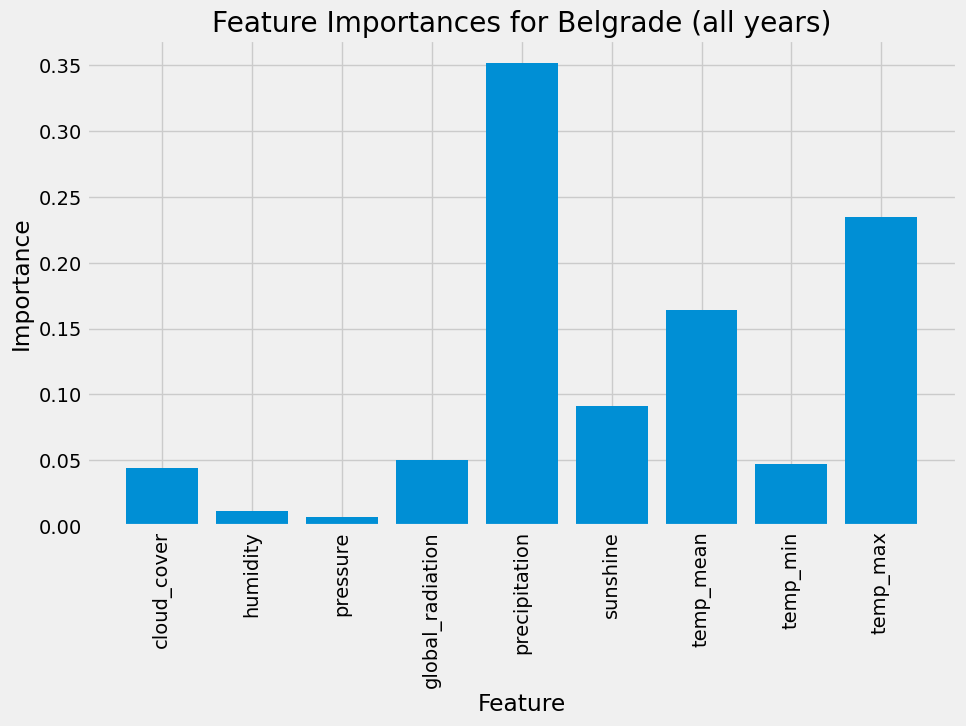

In [54]:
# Plot
plt.style.use('fivethirtyeight')
x_values = list(range(len(newarray)))

plt.figure(figsize=(10,6))
plt.bar(x_values, newarray)  # vertical by default
plt.xticks(x_values, wx_list, rotation=90)
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.title('Feature Importances for Belgrade (all years)')

# Save
os.makedirs(os.path.join(path, 'Visualizations'), exist_ok=True)
plt.savefig(os.path.join(path, 'Visualizations', 'Belgrade_feature_importances.png'), bbox_inches='tight')
plt.show()